# Approximate Sparse Reconstruction of a Sinc Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import *
from hybridqsp.quantum import qhw
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analyisis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

ModuleNotFoundError: No module named 'hybridqsp.analysis'

## Signal Generation
We construct a synthetic signal composed of multiple sinusoidal components in order to study sparse Fourier representations.

In [16]:
N = 256

t = np.linspace(-10, 10, N)

x = np.sinc(t)

# Target state 
target_f = x/np.linalg.norm(x)

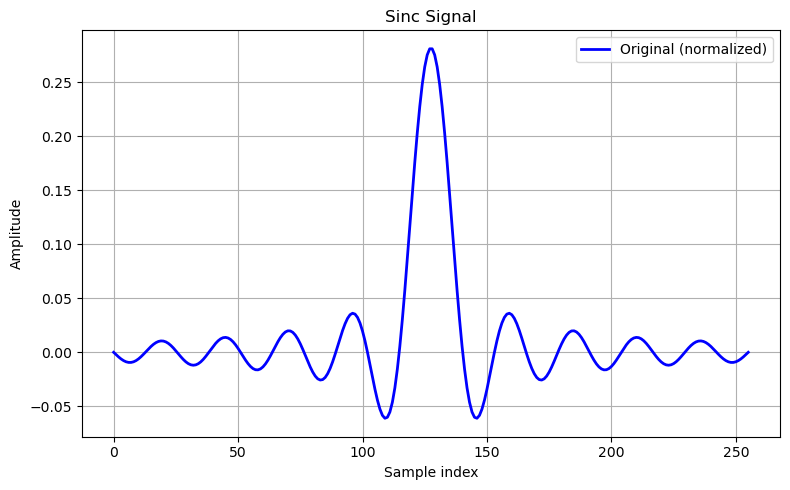

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Classical Search For best compression

In [22]:
def search_sparse_haar_representations(
    signal,
    tolerance=0.02,
    threshold_ratios=None
):
    """
    Search for sparse Haar-packet representations
    that satisfy a reconstruction-error tolerance.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.

    tolerance : float, optional
        Maximum allowed trace distance.

    threshold_ratios : list, optional
        Relative threshold values with respect to
        max(abs(coefficients)).

    Returns
    -------
    list
        Accepted sparse configurations.
    """

    signal = np.asarray(signal, dtype=float)

    N = len(signal)

    # Maximum allowed decomposition level
    max_level = int(np.log2(N))

    levels = list(range(1, max_level + 1))

    if threshold_ratios is None:

        threshold_ratios = [
            0.001,
            0.002,
            0.005,
            0.01,
            0.02,
            0.05,
            0.1
        ]

    accepted_results = []

    for level in levels:

        # Haar packet decomposition
        coeffs = haar_packet_transform(
            signal,
            level=level
        )

        # Maximum coefficient magnitude
        max_coeff = np.max(np.abs(coeffs))

        for ratio in threshold_ratios:

            threshold = ratio * max_coeff

            # Threshold coefficients
            coeffs_sparse = magnitude_threshold(
                coeffs,
                threshold=threshold
            )

            # Reconstruction
            reconstructed_signal = (
                inverse_haar_packet_transform(
                    coeffs_sparse,
                    level=level
                )
            )

            # Metrics
            D = trace_distance(
                signal,
                reconstructed_signal
            )

            F = state_fidelity(
                signal,
                reconstructed_signal
            )

            # Sparsity
            nonzero = np.count_nonzero(
                coeffs_sparse
            )

            sparsity_ratio = (
                nonzero / len(coeffs_sparse)
            )

            # Keep acceptable results
            if D < tolerance:

                result = {
                    "level": level,
                    "threshold": threshold,
                    "nonzero": nonzero,
                    "sparsity_ratio": sparsity_ratio,
                    "trace_distance": D,
                    "fidelity": F
                }

                accepted_results.append(result)

                print(
                    f"Level={level} | "
                    f"Threshold={threshold:.3e} | "
                    f"Nonzero={nonzero} | "
                    f"Sparsity={sparsity_ratio:.3f} | "
                    f"Trace Distance={D:.6e} | "
                    f"Fidelity={F:.6f}"
                )

    return accepted_results

In [24]:
results = search_sparse_haar_representations(
    signal,
    tolerance=0.02
)

Level=1 | Threshold=1.396e-03 | Nonzero=244 | Sparsity=0.953 | Trace Distance=6.591841e-04 | Fidelity=1.000000
Level=1 | Threshold=2.793e-03 | Nonzero=230 | Sparsity=0.898 | Trace Distance=2.672570e-03 | Fidelity=0.999993
Level=1 | Threshold=6.982e-03 | Nonzero=182 | Sparsity=0.711 | Trace Distance=1.087292e-02 | Fidelity=0.999882
Level=2 | Threshold=1.897e-03 | Nonzero=228 | Sparsity=0.891 | Trace Distance=1.516677e-03 | Fidelity=0.999998
Level=2 | Threshold=3.793e-03 | Nonzero=200 | Sparsity=0.781 | Trace Distance=4.398279e-03 | Fidelity=0.999981
Level=2 | Threshold=9.483e-03 | Nonzero=154 | Sparsity=0.602 | Trace Distance=1.280326e-02 | Fidelity=0.999836
Level=3 | Threshold=2.286e-03 | Nonzero=214 | Sparsity=0.836 | Trace Distance=2.485228e-03 | Fidelity=0.999994
Level=3 | Threshold=4.572e-03 | Nonzero=186 | Sparsity=0.727 | Trace Distance=5.691998e-03 | Fidelity=0.999968
Level=3 | Threshold=1.143e-02 | Nonzero=138 | Sparsity=0.539 | Trace Distance=1.614913e-02 | Fidelity=0.999739
L